
# Random Forest Regression

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import matplotlib.pyplot as plt

## 2. Create Dataset

In [2]:
import pandas as pd
import numpy as np

n_samples = 200

exp = np.random.randint(1, 25, n_samples)
projects = np.random.randint(1, 16, n_samples)

# Generate 'Salary' with a simpler linear relationship and added noise
# Salary = Base + (Exp_factor * EXP) + (Projects_factor * Projects) + Noise

# Define constants for salary calculation for clarity
base_salary_val = 50
exp_factor = 3.0
projects_factor = 7.0
noise_std_dev = 20

# Calculate salary by combining all components into one concise expression
salary = base_salary_val + \
         (exp * exp_factor) + \
         (projects * projects_factor) + \
         np.random.normal(0, noise_std_dev, n_samples)

# Ensure salaries are reasonably positive, setting a minimum
salary = np.maximum(salary, 30)

# Create the DataFrame
data = {
    'EXP': exp,
    'Projects': projects,
    'Salary': salary
}
df = pd.DataFrame(data)

print("Generated Extended Dataset:")
display(df.head())

Generated Extended Dataset:


,EXP,Projects,Salary
0,8,7,138.362972
1,23,5,162.347259
2,24,15,210.642103
3,24,6,166.542750
4,14,1,83.915969


## 3. Separate Features and Target

In [3]:
X = df[['EXP', 'Projects']]
y = df['Salary']

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,EXP,Projects
0,8,7
1,23,5
2,24,15
3,24,6
4,14,1



Target (y):


,Salary
0,138.362972
1,162.347259
2,210.642103
3,166.542750
4,83.915969


## 4. Train-Test Split

In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)


Training Shape: (160, 2)
Testing Shape : (40, 2)



## 5. Bootstrap Sampling

Random Forest creates multiple random datasets using sampling with replacement.


In [5]:

sample_1 = df.sample(n=len(df), replace=True, random_state=1)
sample_2 = df.sample(n=len(df), replace=True, random_state=2)

print("Bootstrap Sample 1")
display(sample_1)

print("Bootstrap Sample 2")
display(sample_2)


Bootstrap Sample 1


,EXP,Projects,Salary
37,5,12,129.259004
140,22,6,146.909173
72,1,10,114.599612
137,23,10,154.025750
133,18,3,124.149411
...,...,...,...
144,22,3,129.495523
156,5,9,163.451413
45,21,4,108.089549
195,24,13,212.700278


Bootstrap Sample 2


,EXP,Projects,Salary
168,21,6,169.913951
15,18,2,145.855541
72,1,10,114.599612
22,21,6,163.235513
43,13,9,166.556316
...,...,...,...
155,10,5,153.066225
195,24,13,212.700278
79,18,10,170.739964
130,23,11,220.404870


## 6. Create Random Forest Regressor

In [6]:

model = RandomForestRegressor(
    n_estimators=100,
    max_depth=4,
    bootstrap=True,
    oob_score=True,
    random_state=42
)

model


RandomForestRegressor(max_depth=4, oob_score=True, random_state=42)

## 7. Train the Model

In [7]:

model.fit(X_train, y_train)

print("Model trained successfully.")


Model trained successfully.


## 8. Predictions

In [8]:

predictions = model.predict(X_test)

results = pd.DataFrame({
    'Actual Salary': y_test.values,
    'Predicted Salary': predictions
})

results


,Actual Salary,Predicted Salary
0,128.589350,131.953095
1,145.855541,116.627724
2,135.703162,133.255766
3,164.976224,157.682066
4,140.564044,123.211884
5,149.377642,151.161458
6,191.929152,156.786075
7,149.450359,164.925061
8,154.965693,153.093056
9,108.089549,144.228618


## 9. Predict New Data Point

In [9]:
# Example new data point for prediction based on the extended dataset's features
# Keeping the original values, as they fall within the new plausible ranges for EXP (1-24) and Projects (1-15)
new_data_point = pd.DataFrame([{'EXP': 4, 'Projects': 3}])

# Convert new_data_point to NumPy array to avoid UserWarning about feature names
prediction = model.predict(new_data_point.values)

print("Predicted Salary for new data point (EXP=4, Projects=3):")
print(f"Salary: {prediction[0]:.2f}")

Predicted Salary for new data point (EXP=4, Projects=3):
Salary: 83.65


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(



## 10. Individual Tree Predictions

Each tree predicts separately.
Random Forest averages all predictions.


In [10]:
all_predictions = []

# Define the new data point for individual tree predictions
new_data_point_for_trees = pd.DataFrame([{'EXP': 4, 'Projects': 3}])

print(f"Individual tree predictions for EXP=4, Projects=3:")
for i, tree_model in enumerate(model.estimators_[:5]): # Limiting to first 5 trees for brevity
    # Convert new_data_point_for_trees to NumPy array to avoid UserWarning about feature names
    pred = tree_model.predict(new_data_point_for_trees.values)[0]
    all_predictions.append(pred)
    print(f"Tree {i+1} Prediction: {pred:.2f}")

print("\nAverage Prediction from these trees: ", np.mean(all_predictions))

Individual tree predictions for EXP=4, Projects=3:
Tree 1 Prediction: 73.56
Tree 2 Prediction: 61.55
Tree 3 Prediction: 51.49
Tree 4 Prediction: 107.82
Tree 5 Prediction: 55.44

Average Prediction from these trees:  69.97023247803376



## 11. OOB Score (Out-of-Bag Score)

Rows not selected during bootstrap sampling become OOB samples.

Random Forest uses them for internal validation.


In [11]:

print("OOB Score:", model.oob_score_)


OOB Score: 0.6626523350316522


## 12. Evaluation Metrics

In [12]:

mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE : 17.671939297624917
MSE : 526.6462860635015
RMSE: 22.948775262821794
R2 Score: 0.6041763113166339


## 13. Feature Importance

In [13]:

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance_df


,Feature,Importance
0,EXP,0.33184
1,Projects,0.66816


## 14. Visualize Feature Importance

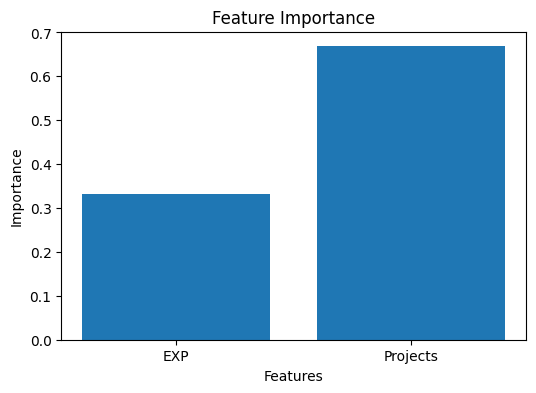

In [14]:

plt.figure(figsize=(6,4))

plt.bar(
    importance_df['Feature'],
    importance_df['Importance']
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Feature Importance")

plt.show()



## 15. Hyperparameter Tuning Example


In [17]:
# Change as per requirement
tuned_model = RandomForestRegressor(
    n_estimators=150,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    bootstrap=True,
    oob_score=True,
    random_state=42
)

tuned_model.fit(X_train, y_train)

tuned_predictions = tuned_model.predict(X_test)

print("Tuned OOB Score:", tuned_model.oob_score_)
print("Tuned R2 Score :", r2_score(y_test, tuned_predictions))


Tuned OOB Score: 0.6560879321020906
Tuned R2 Score : 0.604552007534161



# 16. Final Summary

Random Forest:

- Builds many decision trees
- Uses bootstrap sampling
- Uses random feature selection
- Averages predictions
- Reduces overfitting
- Produces stable predictions

Main concepts learned:

- Ensemble Learning
- Bootstrap Sampling
- OOB Score
- Feature Importance
- Hyperparameter Tuning
